### **Fase 0**: Import Generico

In [1]:
import os
import sys
import importlib
from google.colab import drive
import matplotlib.pyplot as plt

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print("Drive già montato, salto il mount.")

sys.path.append('/content/drive/MyDrive/progetto_immunogold/scripts')
importlib.invalidate_caches()

import common
importlib.reload(common)
from common import *

print(f"Device attivo: {device}")
print(paths)
log('Notebook avviato correttamente')

Mounted at /content/drive
Device attivo: cpu
{'raw_images': '/content/drive/MyDrive/progetto_immunogold/raw_images', 'annotations': '/content/drive/MyDrive/progetto_immunogold/annotations', 'patches_images': '/content/drive/MyDrive/progetto_immunogold/patches/images', 'patches_coordinates': '/content/drive/MyDrive/progetto_immunogold/patches/coordinates', 'patches_density': '/content/drive/MyDrive/progetto_immunogold/patches/density_maps', 'checkpoints': '/content/drive/MyDrive/progetto_immunogold/checkpoints', 'logs': '/content/drive/MyDrive/progetto_immunogold/logs'}
[2026-09-23 08:23] Notebook avviato correttamente


### **Fase 1**: Preparazione immagine e rilevamento blob per singola immagine


1.   Funzione *rileva_maschera_scale_bar*: rileva la presenza della scalebar dell'immagine del microscopio, così che non si comporti come un artefatto nel conteggio finale dei puntini.

2.   Funzione *prepara_immagine_per_detector*: riceve in input il percorso della patch da processare, apre l'immagine, la riduce se necessario a 2 canali (scala di grigi) e normalizza i valori dell'immagine nell'intervallo [0,1].*Return 1.0 - arr* è necessario per l'inversione dell'immagine (i pixel scuri diventano chiari e viceversa, compatibilimente con il funzionamento di blob_log). Considera già l'effetto del filtro scalebar

3.   Funzione *rileva_blob_log*: riceve 4 parametri in input:il percorso della patch, il sigma già calcolato per quella patch, il *fattore_range* che decide quanto allargare la finestra di ricerca del blob detector rispetto al sigma in input (es. 0.3 con sigma = 1 --> 0.7 - 1.3), *num_sigma* ovvero il numero di scale intermedie da testare nell'intervallo appena creato con *fattore_range* e *threshold*, l'iperparametro principale di questo strumento

  (**threshold** è il parametro su cui costruiremo davvero il "tuning" del baseline: valori più bassi rilevano più blob (rischio falsi positivi su rumore/texture), valori più alti sono più selettivi (rischio di perdere puntini deboli o sovrapposti). Lo prove­remo empiricamente sul validation set.)

  **Output:** array numpy con una riga per ogni blob trovato; tre colonne per riga:

1.   y (riga del pixel centrale),
2.   x (colonna),
3.   sigma (la scala a cui è stato rilevato, cioè una stima della sua dimensione).

Il numero di blob rilevati nella patch è quindi **len(blobs)**, quello che confronterai con **n_punti_attesi**.



In [ ]:
import datetime

FATTORE_RANGE = 0.3
NUM_SIGMA = 5
THRESHOLD = 0.175

from skimage.feature import blob_log
from scipy.ndimage import uniform_filter, binary_dilation

def rileva_maschera_scale_bar(arr, soglia_scurezza=0.05, soglia_std_locale=0.01, dimensione_finestra=9):
    arr_norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    media_locale = uniform_filter(arr_norm, size=dimensione_finestra)
    media_quadrati_locale = uniform_filter(arr_norm**2, size=dimensione_finestra)
    varianza_locale = np.maximum(media_quadrati_locale - media_locale**2, 0)
    std_locale = np.sqrt(varianza_locale)
    return (arr_norm < soglia_scurezza) & (std_locale < soglia_std_locale)


def prepara_immagine_per_detector(patch_path):
    with Image.open(patch_path) as img:
        arr = np.array(img)
    if arr.ndim == 3:
        arr = arr.mean(axis=-1)
    arr = arr.astype(np.float64)
    arr_norm = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    immagine_per_detector = 1.0 - arr_norm  # nessun mascheramento qui: l'immagine resta intatta
    return immagine_per_detector, arr  # arr (originale) serve dopo, per individuare la scale bar


def rileva_blob_log(patch_path, sigma_px, fattore_range=FATTORE_RANGE, num_sigma=NUM_SIGMA,
                     threshold=THRESHOLD, escludi_scale_bar=True, margine_scale_bar=3):
    immagine, arr_originale = prepara_immagine_per_detector(patch_path)

    min_sigma = sigma_px * (1 - fattore_range)
    max_sigma = sigma_px * (1 + fattore_range)

    blobs = blob_log(immagine, min_sigma=min_sigma, max_sigma=max_sigma,
                      num_sigma=num_sigma, threshold=threshold)

    if escludi_scale_bar and len(blobs) > 0:
        maschera = rileva_maschera_scale_bar(arr_originale)
        if maschera.any():
            maschera_allargata = binary_dilation(maschera, iterations=margine_scale_bar)
            dentro_maschera = np.array([
                maschera_allargata[int(np.clip(round(y), 0, maschera_allargata.shape[0]-1)),
                                    int(np.clip(round(x), 0, maschera_allargata.shape[1]-1))]
                for y, x, sigma in blobs
            ])
            blobs = blobs[~dentro_maschera]

    return blobs

### **Fase 2**: applicazione dell'algoritmo baseline sulla porzione "*val*" del dataset

split_df e mappa_patch definisco i file da cui prendere le informazioni riguardo le patch da utilizzare (in split_immagini viene detto quali immagini appartengono al validation set mentre in mappa_patch viene spiegato a quali immagini appartengono le varie patch).

Il ciclo *for* permette l'utilizzo della funzione che abbiamo definito in precedenza su tutte le patch.

*except* si occupa di rilevare eventuali anomalie nel calcolo dei blob (informazioni sul tipo di errore riportate nel file log)

*   I risultati sono aggregati in una tabella finale **blob_df** che contiene il numero di blob e altre informazioni importati (percorso patch, immagine di appartenenza, classe di calibrazione)



In [3]:
split_df = pd.read_csv(os.path.join(paths['annotations'], 'split_immagini.csv'))
mappa_patch = pd.read_csv(os.path.join(paths['annotations'], 'mappa_patch.csv'))

val_immagini = split_df[split_df['split'] == 'val']['id_immagine']
patch_val = mappa_patch[mappa_patch['id_immagine'].isin(val_immagini)].reset_index(drop=True)

print(f"Patch nel validation set: {len(patch_val)}")

risultati_blob = []
patch_fallite = 0

for i, riga in patch_val.iterrows():
    patch_path = riga['patch_path']
    sigma_px = riga['sigma_px']

    try:
        blobs = rileva_blob_log(patch_path, sigma_px)
    except Exception as e:
        patch_fallite += 1
        log(f"ATTENZIONE - blob_log fallito su {patch_path}: {e}")
        continue

    risultati_blob.append({
        'patch_path': patch_path,
        'id_immagine': riga['id_immagine'],
        'classe_calibrazione': riga['classe_calibrazione'],
        'n_blob_rilevati': len(blobs),
    })

    if (i + 1) % 50 == 0:
        print(f"Elaborate {i + 1}/{len(patch_val)} patch...")

print(f"Completato: {len(risultati_blob)} patch elaborate, {patch_fallite} fallite")

blob_df = pd.DataFrame(risultati_blob)
display(blob_df.head())

Patch nel validation set: 315
Elaborate 50/315 patch...
Elaborate 100/315 patch...
Elaborate 150/315 patch...
Elaborate 200/315 patch...
Elaborate 250/315 patch...
Elaborate 300/315 patch...
Completato: 315 patch elaborate, 0 fallite


,patch_path,id_immagine,classe_calibrazione,n_blob_rilevati
0,/content/drive/MyDrive/progetto_immunogold/pat...,SA-MAG_X12k_JEM-1400 Flash_22429,classe_6,3
1,/content/drive/MyDrive/progetto_immunogold/pat...,SA-MAG_X12k_JEM-1400 Flash_22429,classe_6,6
2,/content/drive/MyDrive/progetto_immunogold/pat...,SA-MAG_X12k_JEM-1400 Flash_22429,classe_6,6
3,/content/drive/MyDrive/progetto_immunogold/pat...,SA-MAG_X12k_JEM-1400 Flash_22429,classe_6,10
4,/content/drive/MyDrive/progetto_immunogold/pat...,SA-MAG_X12k_JEM-1400 Flash_22429,classe_6,8


**OUTPUT FILTRO SCALE BAR**

Questa sezione è un controllo per l'effetto del filtro sulla scalebar; necessario per assicurarsi che il filtro non abbia rilevato falsi positivi, andando ad oscurare puntini reali

In [4]:
def mostra_maschera_scale_bar(patch_path, ax, margine=3):
    with Image.open(patch_path) as img:
        arr = np.array(img)
    if arr.ndim == 3:
        arr = arr.mean(axis=-1)
    arr = arr.astype(np.float64)

    maschera = rileva_maschera_scale_bar(arr)
    maschera_allargata = binary_dilation(maschera, iterations=margine)  # stesso margine di rileva_blob_log

    ax.imshow(arr, cmap='gray')
    overlay = np.zeros((*arr.shape, 4))
    overlay[maschera_allargata] = [1, 0, 0, 0.5]
    ax.imshow(overlay)
    ax.set_title(f"{maschera_allargata.sum()} px esclusi (margine incluso)", fontsize=9)
    ax.axis('off')

risultati_scale_bar = []

for _, riga in patch_val.iterrows():
    patch_path = riga['patch_path']
    with Image.open(patch_path) as img:
        arr = np.array(img)
    if arr.ndim == 3:
        arr = arr.mean(axis=-1)
    arr = arr.astype(np.float64)

    maschera = rileva_maschera_scale_bar(arr)
    n_px_mascherati = int(maschera.sum())

    if n_px_mascherati > 0:
        risultati_scale_bar.append({
            'patch_path': patch_path,
            'id_immagine': riga['id_immagine'],
            'classe_calibrazione': riga['classe_calibrazione'],
            'n_px_mascherati': n_px_mascherati,
        })

scale_bar_df = pd.DataFrame(risultati_scale_bar).sort_values('n_px_mascherati', ascending=False)
print(f"Patch con maschera scale bar attiva: {len(scale_bar_df)} / {len(patch_val)}")
display(scale_bar_df)

LIMITE_IMMAGINI = None  # es. 20 per limitare il plot, None per mostrarle tutte

df_da_plottare = scale_bar_df if LIMITE_IMMAGINI is None else scale_bar_df.head(LIMITE_IMMAGINI)

n_totale = len(df_da_plottare)
n_col = 4
n_righe = -(-n_totale // n_col)

fig, axes = plt.subplots(n_righe, n_col, figsize=(4 * n_col, 4 * n_righe))
axes = axes.flatten()

for ax, (_, riga) in zip(axes, df_da_plottare.iterrows()):
    mostra_maschera_scale_bar(riga['patch_path'], ax)

for ax in axes[n_totale:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

### **Fase 3**: Calcolo metriche di valutazione:


1.   MAE - Errore Assoluto Medio:

Si calcola l'errore per ogni patch in valore assoluto (|*n_blob_rilevati - n_blob_attesi*|) e si media rispetto a tutte le patch

2.   Bias - Errore Medio con segno:

Prevede il calcolo della stessa formula senza valore assoluto. Di questo valore prendiamo in considerazione il segno ottenuto per capire se si tratta di sovrastima o sottostima del numero di puntini.



In [5]:
def path_coordinate_per_patch(patch_path):
    nome_patch = Path(patch_path).stem
    return os.path.join(paths['patches_coordinates'], f"{nome_patch}_points.csv")

def conta_punti_annotati(patch_path):
    coord_df = pd.read_csv(path_coordinate_per_patch(patch_path))
    return len(coord_df)

blob_df['n_punti_attesi'] = blob_df['patch_path'].apply(conta_punti_annotati)

blob_df['errore_assoluto'] = (blob_df['n_blob_rilevati'] - blob_df['n_punti_attesi']).abs()
blob_df['errore_con_segno'] = blob_df['n_blob_rilevati'] - blob_df['n_punti_attesi']

mae_totale = blob_df['errore_assoluto'].mean()
bias_medio = blob_df['errore_con_segno'].mean()

print(f"MAE sul validation set: {mae_totale:.3f}")
print(f"Errore medio con segno (bias): {bias_medio:.3f}  ({'sovrastima' if bias_medio > 0 else 'sottostima'} sistematica se lontano da 0)")

mae_per_classe = blob_df.groupby('classe_calibrazione')['errore_assoluto'].agg(['mean', 'count'])
mae_per_classe = mae_per_classe.rename(columns={'mean': 'MAE', 'count': 'n_patch'})
display(mae_per_classe.sort_values('MAE', ascending=False))

MAE sul validation set: 1.857
Errore medio con segno (bias): -0.562  (sottostima sistematica se lontano da 0)


,MAE,n_patch
classe_calibrazione,,
classe_9,4.944444,72
classe_6,2.012346,81
classe_5,0.567901,81
classe_2,0.246914,81


### **Fase 4**: Generazione degli output

1.   *Baseline_blob_dettaglio*

Genera un file csv in cui sono riportati tutti i dettagli dell'ultima esecuzione del codice. Qui si possono osservare i singoli errori per ogni patch.

Questo file si sovrascrive ogni volta che facciamo girare il codice (nuova esecuzione, nuovi valori).

2.   *Baseline_tuning_log*

Questo file racchiude la storia delle esecuzioni del codice, affiancate dai valori in input dati alla funzione, così da poter monitorare la struttura più solida del modello, che ha fornito i risultati migliori (affianca i parametri utilizzati al *MAE medio* e al *bias*).

Questo file accumula le varie esecuzioni, creando una vera e propria storia dei tentativi effettuati.

3.   *Baseline_mae_per_classe_log*

Questo file contiene l'errore medio MAE relativo ad ogni classe, ci permette di capire se ci sono delle classi su cui il detector fa più fatica ad annotare i puntini.



In [6]:
# 1. Dettaglio patch-per-patch: sempre sovrascritto, riflette solo l'ultimo run
path_blob_dettaglio = os.path.join(paths['annotations'], 'baseline_blob_dettaglio.csv')
blob_df.to_csv(path_blob_dettaglio, index=False)

# 2. Log dei tentativi di tuning: si accumula, non si sovrascrive mai
path_tuning_log = os.path.join(paths['annotations'], 'baseline_tuning_log.csv')

nuova_riga = pd.DataFrame([{
    'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'fattore_range': FATTORE_RANGE,
    'num_sigma': NUM_SIGMA,
    'threshold': THRESHOLD,
    'mae_totale': mae_totale,
    'bias_medio': bias_medio,
    'n_patch': len(blob_df),
}])

if os.path.exists(path_tuning_log):
    tuning_log_df = pd.read_csv(path_tuning_log)
    tuning_log_df = pd.concat([tuning_log_df, nuova_riga], ignore_index=True)
else:
    tuning_log_df = nuova_riga

tuning_log_df.to_csv(path_tuning_log, index=False)

print(f"MAE questo run: {mae_totale:.3f} (parametri: fattore_range={FATTORE_RANGE}, num_sigma={NUM_SIGMA}, threshold={THRESHOLD})")
display(tuning_log_df.sort_values('mae_totale'))

mae_per_classe_pivot = blob_df.groupby('classe_calibrazione')['errore_assoluto'].mean()

path_mae_per_classe_log = os.path.join(paths['annotations'], 'baseline_mae_per_classe_log.csv')

nuova_riga_classi = {
    'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'fattore_range': FATTORE_RANGE,
    'num_sigma': NUM_SIGMA,
    'threshold': THRESHOLD,
    'mae_totale': mae_totale,
    'bias_medio': bias_medio,
    'n_patch_totale': len(blob_df),
}

for classe in [f'classe_{i}' for i in range(1, 11)]:
    nuova_riga_classi[f'MAE_{classe}'] = mae_per_classe_pivot.get(classe, np.nan)

nuova_riga_classi_df = pd.DataFrame([nuova_riga_classi])

if os.path.exists(path_mae_per_classe_log):
    mae_per_classe_log_df = pd.read_csv(path_mae_per_classe_log)
    mae_per_classe_log_df = pd.concat([mae_per_classe_log_df, nuova_riga_classi_df], ignore_index=True)
else:
    mae_per_classe_log_df = nuova_riga_classi_df

mae_per_classe_log_df.to_csv(path_mae_per_classe_log, index=False)
display(mae_per_classe_log_df)

MAE questo run: 1.857 (parametri: fattore_range=0.3, num_sigma=7, threshold=0.175)


,timestamp,fattore_range,num_sigma,threshold,mae_totale,bias_medio,n_patch
5,2026-09-22 21:07,0.3,5,0.175,1.857143,-0.561905,315
6,2026-09-23 08:28,0.3,7,0.175,1.857143,-0.561905,315
3,2026-09-22 14:27,0.3,5,0.175,2.101587,-0.234921,315
4,2026-09-22 20:53,0.3,5,0.175,2.546032,0.222222,315
2,2026-09-22 14:25,0.3,5,0.200,3.155556,-2.425397,315
1,2026-09-22 10:03,0.3,5,0.150,3.809524,3.333333,315
0,2026-09-22 09:58,0.3,5,0.050,83.952381,83.952381,315


,timestamp,fattore_range,num_sigma,threshold,mae_totale,bias_medio,n_patch_totale,MAE_classe_1,MAE_classe_2,MAE_classe_3,MAE_classe_4,MAE_classe_5,MAE_classe_6,MAE_classe_7,MAE_classe_8,MAE_classe_9,MAE_classe_10
0,2026-09-22 09:58,0.30,5,0.050,83.952381,83.952381,315,NaN,32.000000,NaN,NaN,43.320988,61.123457,NaN,NaN,213.791667,NaN
1,2026-09-22 10:03,0.30,5,0.150,3.809524,3.333333,315,NaN,0.641975,NaN,NaN,1.111111,2.037037,NaN,NaN,12.402778,NaN
2,2026-09-22 14:25,0.30,5,0.200,3.155556,-2.425397,315,NaN,0.296296,NaN,NaN,0.777778,3.320988,NaN,NaN,8.861111,NaN
3,2026-09-22 14:27,0.30,5,0.175,2.101587,-0.234921,315,NaN,0.320988,NaN,NaN,0.641975,2.000000,NaN,NaN,5.861111,NaN
4,2026-09-22 14:31,0.25,5,0.175,2.292063,-0.546032,315,NaN,0.320988,NaN,NaN,0.617284,2.493827,NaN,NaN,6.166667,NaN
5,2026-09-22 20:53,0.30,5,0.175,2.546032,0.222222,315,NaN,0.716049,NaN,NaN,1.160494,2.444444,NaN,NaN,6.277778,NaN
6,2026-09-22 21:07,0.30,5,0.175,1.857143,-0.561905,315,NaN,0.246914,NaN,NaN,0.567901,1.987654,NaN,NaN,4.972222,NaN
7,2026-09-23 08:28,0.30,7,0.175,1.857143,-0.561905,315,NaN,0.246914,NaN,NaN,0.567901,2.012346,NaN,NaN,4.944444,NaN


### **Fase 5**: Visualizzazione grafica del risultato

Vengono plottate 6 patch, scelte come segue:

*   **Patch peggiori - MAE maggiore (3)**: verifichiamo dove il blob detector tende a sbagliare maggiormente.
*   **Patch migliori - MAE minore (2)**: verifichiamo le patch su cui il blob detector generalizza meglio
*   **Patch senza annotazioni (1)**: verifichiamo se il blob detector annota anche dove effettivamente non ci sono puntini



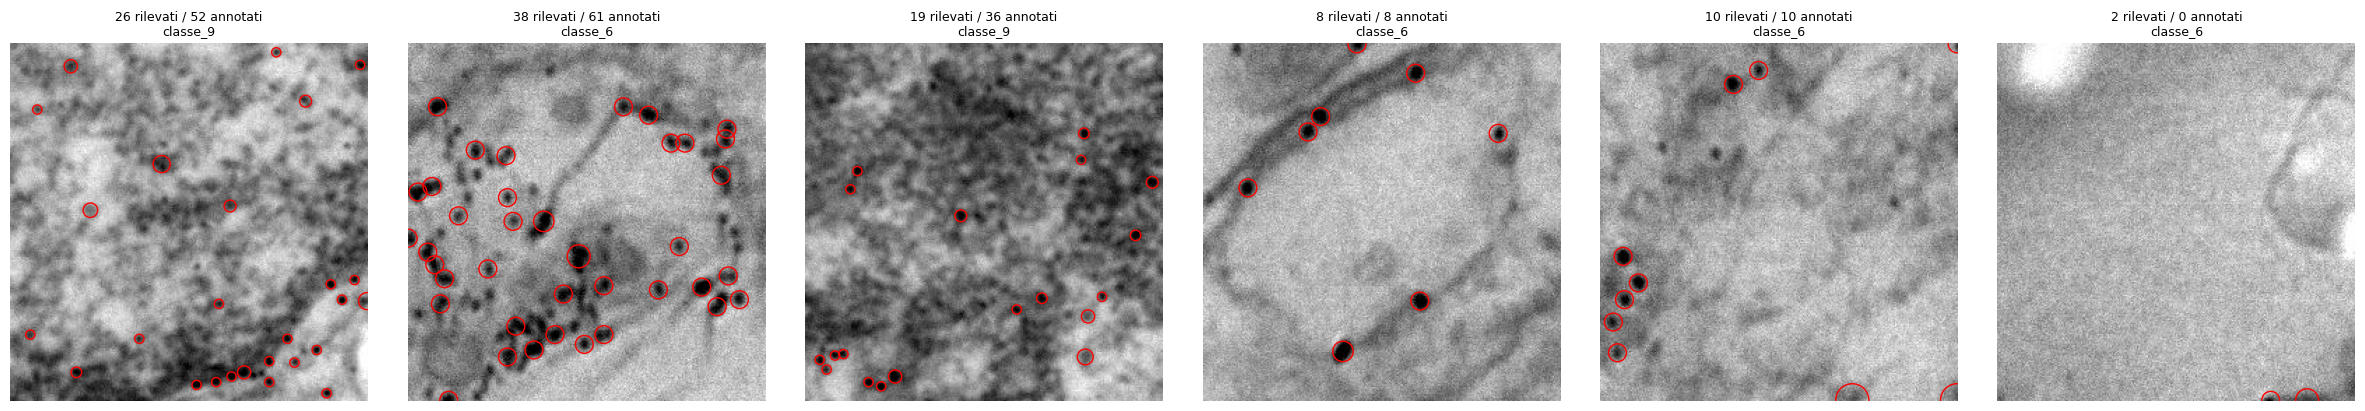

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def mostra_blob_su_patch(patch_path, blobs, ax, n_punti_attesi=None, classe=None):
    with Image.open(patch_path) as img:
        arr = np.array(img)

    ax.imshow(arr, cmap='gray')
    for y, x, sigma in blobs:
        raggio = sigma * np.sqrt(2)  # conversione standard di skimage: raggio reale ≈ sigma * sqrt(2)
        cerchio = patches.Circle((x, y), raggio, color='red', linewidth=1, fill=False)
        ax.add_patch(cerchio)

    titolo = f"{len(blobs)} rilevati"
    if n_punti_attesi is not None:
        titolo += f" / {n_punti_attesi} annotati"
    if classe is not None:
        titolo += f"\n{classe}"
    ax.set_title(titolo, fontsize=9)
    ax.axis('off')


peggiori = blob_df.sort_values('errore_assoluto', ascending=False).head(3)
migliori = blob_df[blob_df['n_punti_attesi'] > 0].sort_values('errore_assoluto', ascending=True).head(2)
solo_sfondo = blob_df[blob_df['n_punti_attesi'] == 0].sort_values('n_blob_rilevati', ascending=False).head(1)

patch_da_ispezionare = pd.concat([peggiori, migliori, solo_sfondo]).drop_duplicates(subset='patch_path')

n = len(patch_da_ispezionare)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]

for ax, (_, riga) in zip(axes, patch_da_ispezionare.iterrows()):
    sigma_px = mappa_patch.loc[mappa_patch['patch_path'] == riga['patch_path'], 'sigma_px'].iloc[0]
    blobs = rileva_blob_log(riga['patch_path'], sigma_px)
    mostra_blob_su_patch(riga['patch_path'], blobs, ax,
                         n_punti_attesi=riga['n_punti_attesi'],
                         classe=riga['classe_calibrazione'])

plt.tight_layout()
plt.show()